Questo homework ha l’obiettivo di affrontare un problema di classificazione, cercando di ottenere le migliori prestazioni possibili, utilizzando i modelli e le metodologie viste a lezione. Il dataset da utilizzare è CIFAR10: contiene 60,000 immagini (50,000 di training e 10,000 di test) divise in 10 classi, a risoluzione 32x32 pixel, a colori. Questa è la pagina di riferimento del dataset.

Nello specifico, i requisiti dell’homework sono:

caricare correttamente il dataset CIFAR10;
utilizzare i seguenti modelli di classificazione: regressione logistica, k-NN, SVM, decision tree;
effettuare opportunamente la model selection;
riportare le prestazioni ottenuti, secondo le metriche di valutazione appropriate.
La strategia di esecuzione di ciascuna di queste fasi è a scelta dello studente. La valutazione dell’homework terrà conto della correttezza metodologica, della correttezza dell’implementazione e della completezza dell’approccio di ricerca del modello migliore.

Nel caso in cui l’allenamento dei modelli risulti eccessivamente dispensioso in termini di tempo, è possibile valutare l’ipotesi di sotto-campionamento del dataset.

Consegna
La consegna del MHW dovrà essere effettuata su GitHub, in un repository chiamato esattamente hw2, e dovrà includere:

il notebook contenente la soluzione;
una presentazione in PowerPoint, da esporre in sede di esame, che includa:
descrizione del dataset;
descrizione della metodologia adottata;
descrizione dei risultati.

In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import seaborn as sns

In [2]:
from tensorflow.keras.datasets import cifar10 #caricamento dataset


(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

#per utilizzare Scikit-Learne e GridSearchCV è necessario avere array a 1D
y_train = y_train.ravel()
y_test = y_test.ravel()

#Per ridurre i tempi computazionali di GridSearchCV, si applica un campionamento casuale stratificato 
#riducendo il dataset, mantenendo la distribuzione originale delle classi.
X_train_rid, _, y_train_rid, _ = train_test_split(
    X_train, y_train, 
    train_size=0.2, 
    stratify=y_train, 
    random_state=42
)

X_test_rid, _, y_test_rid, _ = train_test_split(
    X_test, y_test, 
    train_size=0.2, 
    stratify=y_test, 
    random_state=42
)
#per modelli classici come quelli che andremo ad utilizzare dobbiamo ridurre le dimensioni da 3D a 2D
X_train_rid= X_train_rid.reshape((X_train_rid.shape[0], -1))
X_test_rid = X_test_rid.reshape((X_test_rid.shape[0], -1))

print(X_train_rid.shape)
print(y_train_rid.shape)
print(X_test_rid.shape)
print(y_test_rid.shape)


2025-04-30 21:18:25.789827: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746047906.041676      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746047906.114400      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)
(5000, 3072)
(5000,)
(1000, 3072)
(1000,)


In [3]:
#è buon uso standardizzare i dati per evitare che valori più grandi acquisiscano maggiore importanza nel training dei modelli
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_rid)
X_test_scaled = scaler.transform(X_test_rid)

In [9]:
#definizione modelli, da usare nella GridSearchCV
modelli = [
    ('Logistic Regression', LogisticRegression(solver='liblinear', random_state=42)),
    ('SVM', SVC(random_state=42)),
    ('KNN', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(criterion ='entropy', random_state=42))
]
#definzione griglia parametri, serve a trovare la configurazione migliore attraverso GridSearchCV
param_grid = {
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'max_iter': [100, 1000],
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel' : ['linear', 'rbf'],
        'gamma' : ['scale', 'auto'],
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights' : ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine'], 
    },
    'Decision Tree': {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    }
}


Fitting 5 folds for each of 6 candidates, totalling 30 fits
I migliori parametri per Logistic Regression sono: {'C': 0.1, 'max_iter': 100}
Fitting 5 folds for each of 12 candidates, totalling 60 fits
I migliori parametri per SVM sono: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Fitting 5 folds for each of 32 candidates, totalling 160 fits
I migliori parametri per KNN sono: {'metric': 'cosine', 'n_neighbors': 7, 'weights': 'distance'}
Fitting 5 folds for each of 27 candidates, totalling 135 fits
I migliori parametri per Decision Tree sono: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Accuracy di Logistic Regression: 0.293

Report di classificazione di Logistic Regression:
              precision    recall  f1-score   support

           0       0.34      0.35      0.34       100
           1       0.32      0.31      0.31       100
           2       0.23      0.23      0.23       100
           3       0.17      0.19      0.18       100
           4       0.35     

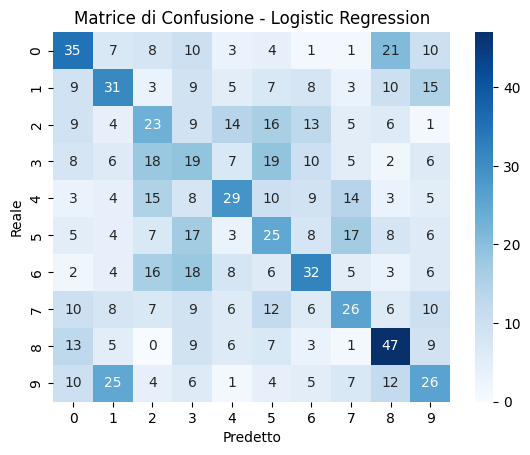

Accuracy di SVM: 0.454

Report di classificazione di SVM:
              precision    recall  f1-score   support

           0       0.53      0.62      0.57       100
           1       0.49      0.52      0.50       100
           2       0.32      0.31      0.31       100
           3       0.27      0.35      0.31       100
           4       0.47      0.37      0.41       100
           5       0.38      0.37      0.37       100
           6       0.48      0.44      0.46       100
           7       0.54      0.39      0.45       100
           8       0.57      0.62      0.59       100
           9       0.55      0.55      0.55       100

    accuracy                           0.45      1000
   macro avg       0.46      0.45      0.45      1000
weighted avg       0.46      0.45      0.45      1000



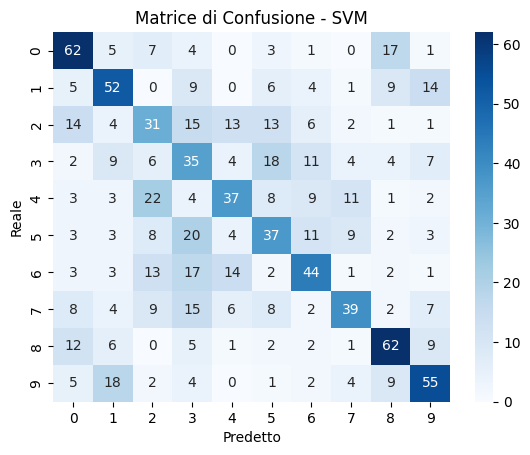

Accuracy di KNN: 0.344

Report di classificazione di KNN:
              precision    recall  f1-score   support

           0       0.38      0.56      0.45       100
           1       0.44      0.32      0.37       100
           2       0.19      0.14      0.16       100
           3       0.23      0.20      0.21       100
           4       0.30      0.43      0.35       100
           5       0.32      0.38      0.35       100
           6       0.27      0.28      0.28       100
           7       0.54      0.27      0.36       100
           8       0.41      0.54      0.46       100
           9       0.43      0.32      0.37       100

    accuracy                           0.34      1000
   macro avg       0.35      0.34      0.34      1000
weighted avg       0.35      0.34      0.34      1000



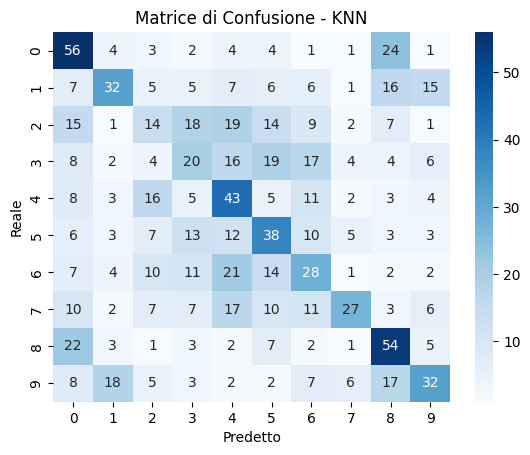

Accuracy di Decision Tree: 0.229

Report di classificazione di Decision Tree:
              precision    recall  f1-score   support

           0       0.28      0.35      0.31       100
           1       0.16      0.15      0.16       100
           2       0.17      0.16      0.16       100
           3       0.17      0.11      0.13       100
           4       0.21      0.34      0.26       100
           5       0.21      0.15      0.17       100
           6       0.27      0.29      0.28       100
           7       0.22      0.20      0.21       100
           8       0.27      0.29      0.28       100
           9       0.30      0.25      0.27       100

    accuracy                           0.23      1000
   macro avg       0.23      0.23      0.22      1000
weighted avg       0.23      0.23      0.22      1000



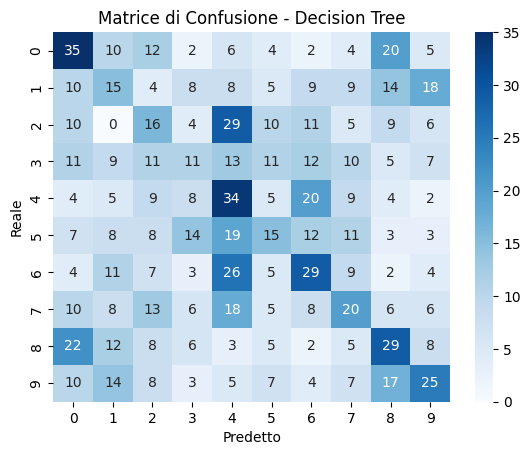

In [10]:
grid_searches = []
for nome, modello in modelli:
    grid_search = GridSearchCV(modello, param_grid[nome], cv=5,scoring = 'accuracy', n_jobs = -1, verbose = 1)
    grid_searches.append((nome, grid_search))

best_models = {}
for nome, grid_search in grid_searches:
    grid_search.fit(X_train_scaled, y_train_rid)
    best_models[nome] = grid_search.best_estimator_
    print(f"I migliori parametri per {nome} sono: {grid_search.best_params_}")

for nome, best_model in best_models.items():
    y_pred = best_model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test_rid, y_pred)
    print(f"Accuracy di {nome}: {accuracy}")
    print(f"\nReport di classificazione di {nome}:" )
    print(classification_report(y_test_rid, y_pred))
    cm = confusion_matrix(y_test_rid, y_pred, labels=best_model.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
    plt.title(f'Matrice di Confusione - {nome}')
    plt.xlabel('Predetto')
    plt.ylabel('Reale')
    plt.show()
